In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)

In [2]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)
X, y = mnist.data, mnist.target
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(70000, 784))

In [3]:
y

array(['5', '0', '4', ..., '4', '5', '6'], shape=(70000,), dtype=object)

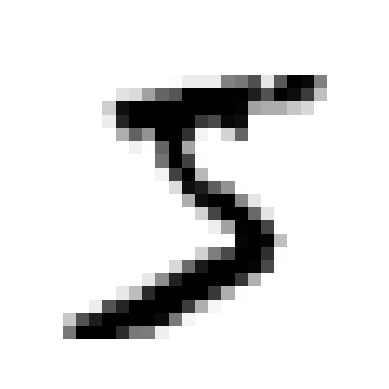

In [4]:
import matplotlib.pyplot as plt

def plot_digit(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap="binary")
    plt.axis("off")

some_digit = X[0]
plot_digit(some_digit)

plt.show()

In [5]:
y[0]

'5'

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5)
X_train.shape, X_test.shape


((35000, 784), (35000, 784))

## Classification Metrics

In [8]:
from sklearn.linear_model import LogisticRegression
lr_clf = LogisticRegression()
lr_clf.fit(X_train, y_train)
y_pred = lr_clf.predict(X_test)
y_pred

c:\Users\user\miniconda3\envs\ds\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


array(['4', '1', '1', ..., '8', '4', '5'], shape=(35000,), dtype=object)

In [9]:
y_test

array(['4', '1', '1', ..., '8', '4', '5'], shape=(35000,), dtype=object)

In [10]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
cm

array([[3355,    0,   20,   10,    7,   28,   17,    7,   25,    8],
       [   1, 3835,   18,   18,    4,   10,    1,   11,   43,   12],
       [  23,   49, 3144,   83,   40,   16,   54,   39,   86,   20],
       [  16,   19,   86, 3156,    6,  122,   12,   34,   62,   31],
       [  10,    8,   26,    9, 3079,    2,   32,   17,   31,  128],
       [  45,   12,   25,  115,   34, 2672,   62,   14,  112,   40],
       [  29,   11,   30,    5,   31,   51, 3222,    4,   20,    2],
       [  20,   10,   47,   25,   29,    8,    1, 3418,   12,  127],
       [  21,   68,   52,   99,   13,   96,   30,   14, 2978,   34],
       [  16,   11,   13,   54,  102,   18,    0,  121,   35, 3122]])

For $n$ classes, the confusion matrix is an $n \times n$ matrix where element $(i, j)$ contains the count of instances with true class $i$ predicted as class $j$.

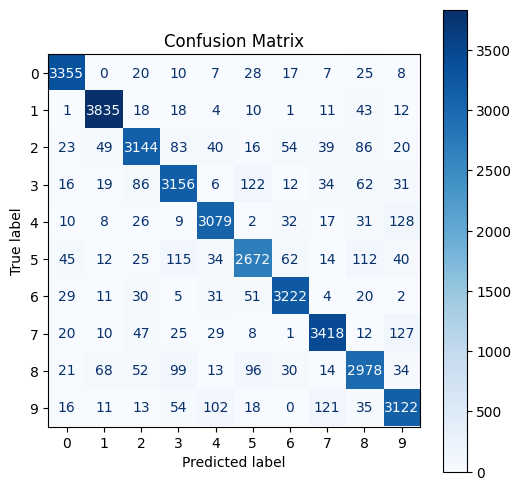

In [11]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lr_clf.classes_)
disp.plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [13]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train)

,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


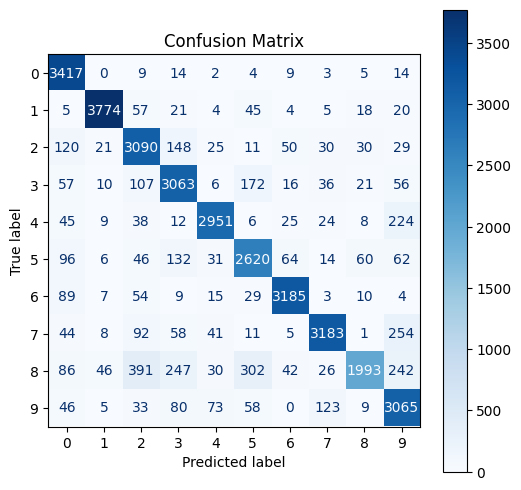

In [14]:
y_pred = sgd_clf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sgd_clf.classes_)
disp.plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [15]:
# from sklearn.tree import DecisionTreeClassifier

# tree_clf = DecisionTreeClassifier()
# tree_clf.fit(X_train, y_train)

# y_pred = tree_clf.predict(X_test)
# cm = confusion_matrix(y_test, y_pred)

# fig, ax = plt.subplots(figsize=(6, 6))
# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=tree_clf.classes_)
# disp.plot(ax=ax, cmap='Blues')
# plt.title('Confusion Matrix')
# plt.show()

In [14]:
# from sklearn.ensemble import RandomForestClassifier

# forest_clf = RandomForestClassifier()
# forest_clf.fit(X_train, y_train)

# y_pred = forest_clf.predict(X_test)
# cm = confusion_matrix(y_test, y_pred)

# fig, ax = plt.subplots(figsize=(6, 6))
# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=forest_clf.classes_)
# disp.plot(ax=ax, cmap='Blues')
# plt.title('Confusion Matrix')
# plt.show()

In [16]:
# from sklearn.neighbors import KNeighborsClassifier

# knn_clf = KNeighborsClassifier()
# knn_clf.fit(X_train, y_train)

# y_pred = knn_clf.predict(X_test)
# cm = confusion_matrix(y_test, y_pred)

# fig, ax = plt.subplots(figsize=(6, 6))
# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn_clf.classes_)
# disp.plot(ax=ax, cmap='Blues')
# plt.title('Confusion Matrix')
# plt.show()

In [17]:
# from sklearn.svm import SVC
# svc_clf = SVC(kernel='rbf')
# svc_clf.fit(X_train, y_train)

# y_pred = svc_clf.predict(X_test)
# cm = confusion_matrix(y_test, y_pred)

# fig, ax = plt.subplots(figsize=(6, 6))
# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svc_clf.classes_)
# disp.plot(ax=ax, cmap='Blues')
# plt.title('Confusion Matrix')
# plt.show()

For multi-class classification with $n$ classes:
$$\text{Accuracy} = \frac{\sum_{i=1}^{n} \text{CM}_{i,i}}{N}$$

Where $\text{CM}_{i,i}$ is the diagonal element (correct predictions) for class $i$, and $N$ is the total number of instances.

**Definition:** The proportion of correctly classified instances out of all instances.

**Limitations:** Accuracy can be misleading for imbalanced datasets. For multi-class problems with class imbalance, consider using balanced accuracy or other metrics.

In [18]:
from sklearn.metrics import accuracy_score

accuracy_multiclass = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy_multiclass:.4f}")

# Or manually from confusion matrix:
accuracy_from_cm = np.trace(cm) / np.sum(cm)


Accuracy: 0.8669


In [19]:
from sklearn.metrics import balanced_accuracy_score

balanced_acc = balanced_accuracy_score(y_test, y_pred)
print(f"Balanced Accuracy: {balanced_acc:.4f}")

Balanced Accuracy: 0.8650


### 3. Precision, Recall, and F1-Score

- True Positives (TP): The diagonal elements.
	- e.g., $TP_{1} = CM_{1,1}$. 
	- These are cases where the actual class and predicted class are the same.
- False Positives (FP): The sum of the corresponding column (excluding the diagonal)
	- e.g., $FP_{1} = \sum_{i\neq 1} CM_{i,1}$. 
	- This means the model predicted this class, but it was actually another class. 
- False Negatives (FN): The sum of the corresponding row (excluding the diagonal). 
	- e.g., $FN_{1} = \sum_{j\neq 1} CM_{1,j}$. 
	- This means the actual class was this one, but the model predicted a different class
- True Negative (TN): The sum of all elements in the confusion matrix that do not belong to that class's row or column.
	- e.g., $FN_{1} = \sum_{i\neq 1} \sum_{j\neq 1} CM_{i,j}$. 
	- These are cases where the actual class was "not X" and the model correctly predicted "not X."

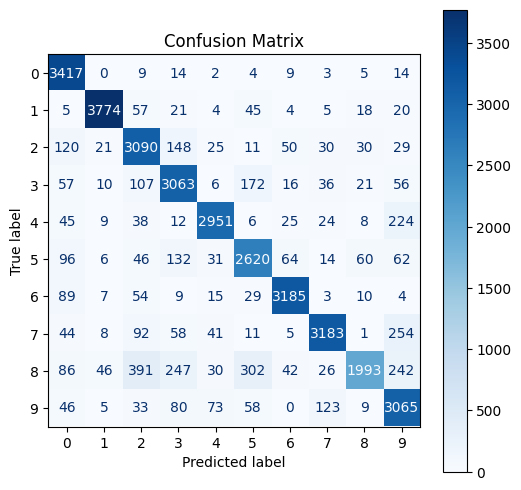

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sgd_clf.classes_)
disp.plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix')
plt.show()


**Per-Class Formulas (One-vs-Rest for each class $i$):**

$$\text{Precision}_i = \frac{TP_i}{TP_i + FP_i}$$

$$\text{Recall}_i = \frac{TP_i}{TP_i + FN_i}$$

$$F_{1,i} = \frac{2}{\frac{1}{\text{Precision}_i} + \frac{1}{\text{Recall}_i}} = 2 \times \frac{\text{Precision}_i \times \text{Recall}_i}{\text{Precision}_i + \text{Recall}_i}$$

In [22]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, target_names=sgd_clf.classes_))

              precision    recall  f1-score   support

           0       0.85      0.98      0.91      3477
           1       0.97      0.95      0.96      3953
           2       0.79      0.87      0.83      3554
           3       0.81      0.86      0.84      3544
           4       0.93      0.88      0.91      3342
           5       0.80      0.84      0.82      3131
           6       0.94      0.94      0.94      3405
           7       0.92      0.86      0.89      3697
           8       0.92      0.59      0.72      3405
           9       0.77      0.88      0.82      3492

    accuracy                           0.87     35000
   macro avg       0.87      0.87      0.86     35000
weighted avg       0.87      0.87      0.86     35000



**Averaging Strategies:**

| Strategy | Formula | Use Case |
|----------|---------|----------|
| **Macro** | $\frac{1}{n} \sum_{i=1}^{n} \text{Metric}_i$ | Treats all classes equally |
| **Weighted** | $\frac{\sum_{i=1}^{n} (\text{Metric}_i \times \text{Support}_i)}{\sum_{i=1}^{n} \text{Support}_i}$ | Accounts for class imbalance |
| **Micro** | $\frac{\sum TP_i}{\sum TP_i + \sum FP_i}$ | Global metric across all classes |

$\text{Support}_i$ is number of true instance for class i

**Use Case Guidelines:**
- **Macro averaging**: When all classes are equally important
- **Weighted averaging**: When dealing with class imbalance
- **Micro averaging**: When you care about overall instance-level performance

**Interpretation of Metrics:**
- **Precision (Positive Predictive Value)**: When the model predicts a positive case, how often is it right? 
- **Recall (Sensitivity/True Positive Rate)**: Out of all actual positive cases, how many did the model find? 
- **F1-Score**: The harmonic mean of precision and recall, ranging from 0 to 1, where 1 is perfect and 0 is the worst. It acts as a strict average that penalizes extreme imbalances between precision and recall, meaning both must be high to achieve a high F1-score. 

In [23]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Default: returns a single metric (averaged)
precision_macro = precision_score(y_test, y_pred, average='macro')
recall_macro = recall_score(y_test, y_pred, average='macro')
f1_macro = f1_score(y_test, y_pred, average='macro')

print(f"Macro Precision: {precision_macro:.4f}")
print(f"Macro Recall: {recall_macro:.4f}")
print(f"Macro F1-Score: {f1_macro:.4f}")

Macro Precision: 0.8712
Macro Recall: 0.8650
Macro F1-Score: 0.8630


In [24]:
precision_weighted = precision_score(y_test, y_pred, average='weighted')
recall_weighted = recall_score(y_test, y_pred, average='weighted')
f1_weighted = f1_score(y_test, y_pred, average='weighted')

print(f"\nWeighted Precision: {precision_weighted:.4f}")
print(f"Weighted Recall: {recall_weighted:.4f}")
print(f"Weighted F1-Score: {f1_weighted:.4f}")


Weighted Precision: 0.8728
Weighted Recall: 0.8669
Weighted F1-Score: 0.8648


In [25]:
precision_micro = precision_score(y_test, y_pred, average='micro')
recall_micro = recall_score(y_test, y_pred, average='micro')
f1_micro = f1_score(y_test, y_pred, average='micro')

print(f"\nMicro Precision: {precision_micro:.4f}")
print(f"Micro Recall: {recall_micro:.4f}")
print(f"Micro F1-Score: {f1_micro:.4f}")


Micro Precision: 0.8669
Micro Recall: 0.8669
Micro F1-Score: 0.8669


### 4. ROC (Receiver Operating Characteristic) Curve and AUC (Binary and Multi-Class)

**True Positive Rate (TPR):**
$$\text{Recall} = \text{TPR} = \frac{TP}{TP + FN}$$

**False Positive Rate (FPR):**
$$\text{Fall-Out} = \text{FPR} = \frac{FP}{FP + TN}$$

**ROC Curve:** A plot of TPR vs. FPR at various threshold settings.

In [46]:
y_5 = (y == '5')
y_train_5 = (y_train == '5')
y_test_5 = (y_test == '5')

y_train_5

array([False, False, False, ..., False, False, False], shape=(35000,))

In [39]:
lr_clf = LogisticRegression(solver='newton-cholesky', max_iter=1000)
lr_clf.fit(X_train, y_train_5)
y_pred = lr_clf.predict(X_test)
y_pred

array([False, False, False, ..., False, False,  True], shape=(35000,))

In [40]:
y_test_5

array([False, False, False, ..., False, False,  True], shape=(35000,))

In [ ]:
y_score = lr_clf.decision_function([some_digit])
y_score

array([1.30199695])

In [ ]:
y_scores = lr_clf.decision_function(X_test)
y_scores

array([-11.79085095,  -9.22727999,  -0.86114626, ...,  -4.14990404,
        -7.46715115,   2.08559922], shape=(35000,))

In [ ]:
(1 / (1 + np.exp(-y_scores)) ).round(3)

array([0.   , 0.   , 0.297, ..., 0.016, 0.001, 0.889], shape=(35000,))

In [67]:
from sklearn.model_selection import cross_val_predict
y_scores = cross_val_predict(lr_clf, X_train, y_train_5, cv=3, method="decision_function")
y_scores

array([ -5.56186648, -19.48150286,  -3.69265275, ...,  -4.12386387,
       -10.08335587, -10.20713871], shape=(35000,))

In [68]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

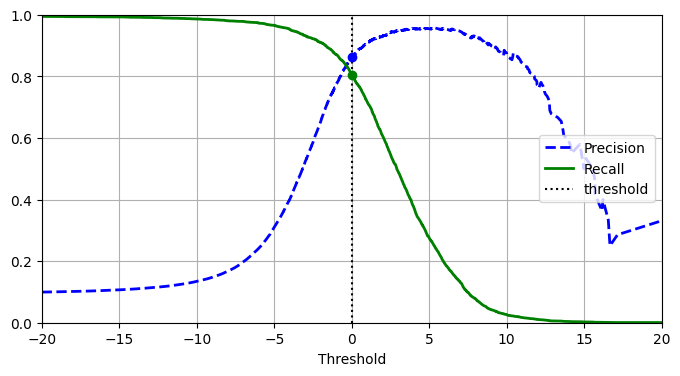

In [78]:
plt.figure(figsize=(8, 4))  # extra code – it's not needed, just formatting
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
plt.vlines(0, 0, 1.0, "k", "dotted", label="threshold")

idx = (thresholds >= 0).argmax()  # first index ≥ threshold
plt.plot(thresholds[idx], precisions[idx], "bo")
plt.plot(thresholds[idx], recalls[idx], "go")
plt.axis([-20, 20, 0, 1])
plt.grid()
plt.xlabel("Threshold")
plt.legend(loc="center right")

plt.show()

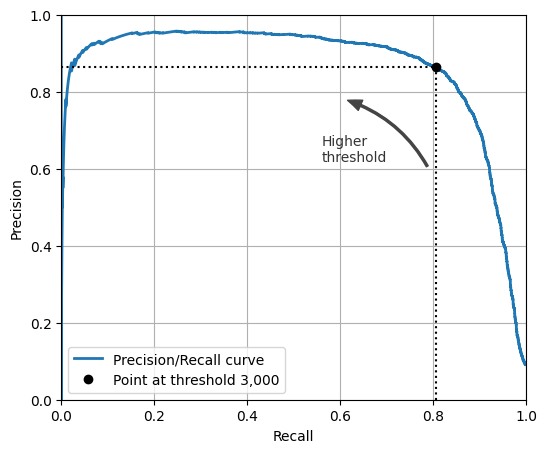

In [ ]:
import matplotlib.patches as patches  # extra code – for the curved arrow

plt.figure(figsize=(6, 5))  # extra code – not needed, just formatting

plt.plot(recalls, precisions, linewidth=2, label="Precision/Recall curve")

plt.plot([recalls[idx], recalls[idx]], [0., precisions[idx]], "k:")
plt.plot([0.0, recalls[idx]], [precisions[idx], precisions[idx]], "k:")
plt.plot([recalls[idx]], [precisions[idx]], "ko",
         label="Point at threshold 3,000")
plt.gca().add_patch(patches.FancyArrowPatch(
    (0.79, 0.60), (0.61, 0.78),
    connectionstyle="arc3,rad=.2",
    arrowstyle="Simple, tail_width=1.5, head_width=8, head_length=10",
    color="#444444"))
plt.text(0.56, 0.62, "Higher\nthreshold", color="#333333")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.axis([0, 1, 0, 1])
plt.grid()
plt.legend(loc="lower left")

plt.show()

In [80]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)

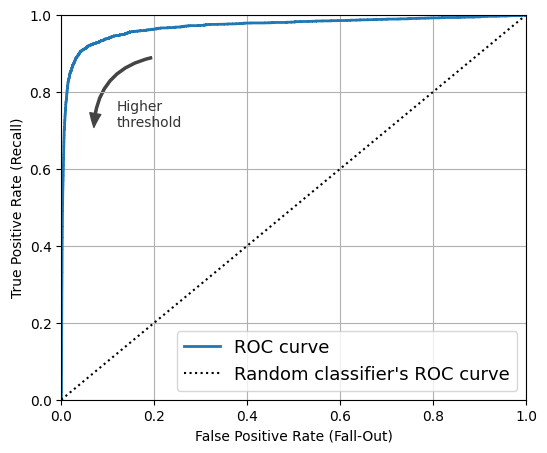

In [82]:
plt.figure(figsize=(6, 5)) 
plt.plot(fpr, tpr, linewidth=2, label="ROC curve")
plt.plot([0, 1], [0, 1], 'k:', label="Random classifier's ROC curve")

plt.gca().add_patch(patches.FancyArrowPatch(
    (0.20, 0.89), (0.07, 0.70),
    connectionstyle="arc3,rad=.4",
    arrowstyle="Simple, tail_width=1.5, head_width=8, head_length=10",
    color="#444444"))
plt.text(0.12, 0.71, "Higher\nthreshold", color="#333333")
plt.xlabel('False Positive Rate (Fall-Out)')
plt.ylabel('True Positive Rate (Recall)')
plt.grid()
plt.axis([0, 1, 0, 1])
plt.legend(loc="lower right", fontsize=13)

plt.show()

**AUC (Area Under the Curve):** The area under the ROC curve, representing the probability that a randomly chosen positive instance is ranked higher than a randomly chosen negative instance.

**Mathematical Formula:**
$$\text{AUC} = \int_0^1 \text{TPR}(\text{FPR}^{-1}(t)) dt$$


**Interpretation:**
- AUC = 0.5: Random classifier
- AUC = 1.0: Perfect classifier
- AUC > 0.9: Excellent
- AUC > 0.8: Good
- AUC > 0.7: Fair

**Multi-Class AUC Averaging:**
- **Micro**: Calculate metrics globally from all classes
- **Macro**: Calculate metric for each class, then average
- **Weighted**: Calculate metric for each class, weighted by support

### 5. Precision-Recall Curve (Binary and Multi-Class)

**Definition:** A plot of precision vs. recall at various threshold settings. More informative than ROC for imbalanced datasets.


**Use Case:** More informative than ROC for imbalanced datasets, especially in multi-class settings.


In [87]:
from sklearn.svm import SVC

y_scores_lr = cross_val_predict(lr_clf, X_train, y_train_5, cv=3, method="decision_function")
y_scores_sgd = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3, method="decision_function")

svc_clf = SVC()
y_scores_svc = cross_val_predict(svc_clf, X_train, y_train_5, cv=3, method="decision_function")


In [88]:
precisions_lr, recalls_lr, thresholds_lr = precision_recall_curve(y_train_5, y_scores_lr)
precisions_sgd, recalls_sgd, thresholds_sgd = precision_recall_curve(y_train_5, y_scores_sgd)
precisions_svc, recalls_svc, thresholds_svc = precision_recall_curve(y_train_5, y_scores_svc)

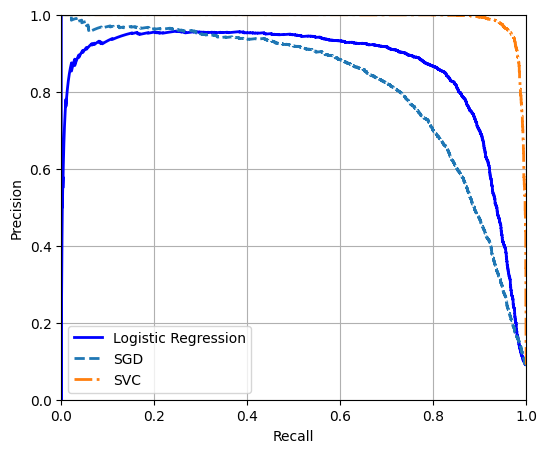

In [89]:
plt.figure(figsize=(6, 5))  # extra code – not needed, just formatting

plt.plot(recalls_lr, precisions_lr, "b-", linewidth=2, label="Logistic Regression")
plt.plot(recalls_sgd, precisions_sgd, "--", linewidth=2, label="SGD")
plt.plot(recalls_svc, precisions_svc, "-.", linewidth=2, label="SVC")

# extra code – just beautifies Figure 3–8
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.axis([0, 1, 0, 1])
plt.grid()
plt.legend(loc="lower left")

plt.show()